# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2381 Комосский Егор Артемович и Рыжиков Иван Сергеевич. Вариант №17.

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения

**Выборочная прямая среднеквадратической регрессии** позволяет описать линейную зависимость между признаками $X$ и $Y$ по методу наименьших квадратов.

Прямая регрессии $Y$ на $X$ имеет вид
$$
\hat y = a_{yx} + b_{yx}x,
$$
где
$$
b_{yx} = r_{xy}\frac{s_y}{s_x}, \qquad a_{yx} = \bar y - b_{yx}\bar x.
$$

Прямая регрессии $X$ на $Y$ имеет вид
$$
\hat x = a_{xy} + b_{xy}y,
$$
где
$$
b_{xy} = r_{xy}\frac{s_x}{s_y}, \qquad a_{xy} = \bar x - b_{xy}\bar y.
$$

**Параболическая регрессия** записывается формулой
$$
\hat y = \beta_0 + \beta_1 x + \beta_2 x^2.
$$

**Выборочное корреляционное отношение** используют для оценки тесноты не только линейной, но и произвольной связи. Для зависимости $Y$ от $X$:
$$
\eta_{yx} = \sqrt{\frac{\sum_j n_j(\bar y_j - \bar y)^2}{\sum_i (y_i - \bar y)^2}}.
$$

Для сравнения моделей используем:
$$
R^2 = 1 - \frac{\sum (y_i-\hat y_i)^2}{\sum (y_i-\bar y)^2},
$$
$$
S_e = \sqrt{\frac{1}{n}\sum (y_i-\hat y_i)^2},
$$
$$
A = \frac{100\%}{n}\sum \left|\frac{y_i-\hat y_i}{y_i}\right|.
$$

## Постановка задачи

Для заданной двумерной выборки
$(X,Y)$ построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Порядок выполнения работы

1. Отобразить двумерную выборку на графике.
2. Для заданной выборки построить уравнения средней квадратичной регрессии $x на $y$ и $y$ на $x$ соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.

3. Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy} \geq | r_{xy} |$ и $\eta_{yx} \geq | r_{xy} |$ выполняются.

4. Для заданной выборки построить корреляционную кривую параболического вида $y = \beta_0 + \beta_1 x + \beta_2 x^2$, сделать выводы.
5. Для заданной выборки построить корреляционную кривую $y = \beta_0 + \frac{\beta_1}{x}$, сделать выводы.
6. Вычислить следующие показатели качества регрессии для каждой кривой и сделать выводы:

    a. теоретический коэффициент детерминации $R^2$

    b. средняя квадратическая ошибка $S_{\varepsilon}$
    
    c. средняя ошибка аппроксимации (приближения) $A$

### Импорт библиотек

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

### Загрузка данных

In [ ]:
df = pd.read_csv("abalone_sample.csv")
df.head()

,Height,Viscera_weight
0,0.160,0.3015
1,0.150,0.2150
2,0.195,0.2245
3,0.170,0.2665
4,0.145,0.1080


Используем столбцы `Height` и `Viscera_weight`.  
Для варианта 17 по списку заданий берём модель: обратно пропорциональная функция
$$
y = \beta_0 + \frac{\beta_1}{x}
$$

## Задача 1

Отобразить двумерную выборку на графике.

Число наблюдений: 108
X = Height
Y = Viscera_weight


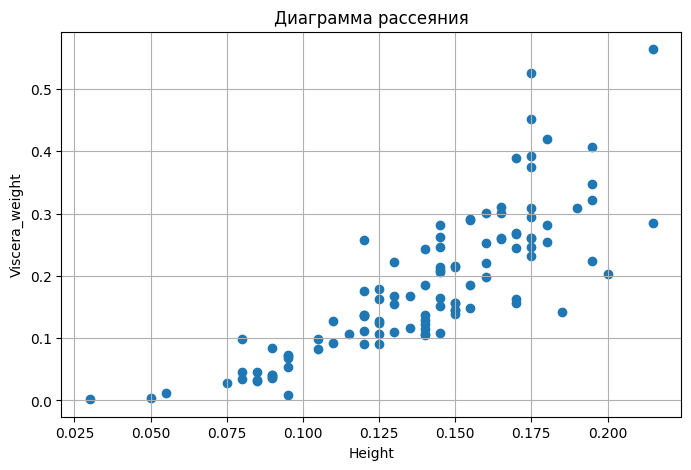

In [ ]:
x = df["Height"].to_numpy(dtype=float)
y = df["Viscera_weight"].to_numpy(dtype=float)
n = len(df)

print("Число наблюдений:", n)
print("X =", "Height")
print("Y =", "Viscera_weight")

plt.figure()
plt.scatter(x, y)
plt.xlabel("Height")
plt.ylabel("Viscera_weight")
plt.title("Диаграмма рассеяния")
plt.show()

По диаграмме рассеяния видно, что между признаками `Height` и `Viscera_weight` есть положительная зависимость.  
Для её более точного описания построим выборочные прямые регрессии.

## Задача 2

Для заданной выборки построить уравнения средней квадратической регрессии $x$ на $y$ и $y$ на $x$. Построить полученные прямые на множестве выборки.

In [ ]:
x_mean = np.mean(x)
y_mean = np.mean(y)

sx = np.sqrt(np.mean((x - x_mean) ** 2))
sy = np.sqrt(np.mean((y - y_mean) ** 2))

r_xy = np.sum((x - x_mean) * (y - y_mean)) / np.sqrt(
    np.sum((x - x_mean) ** 2) * np.sum((y - y_mean) ** 2)
)

b_yx = r_xy * sy / sx
a_yx = y_mean - b_yx * x_mean

b_xy = r_xy * sx / sy
a_xy = x_mean - b_xy * y_mean

print(f"x̄ = {x_mean:.6f}")
print(f"ȳ = {y_mean:.6f}")
print(f"s_x = {sx:.6f}")
print(f"s_y = {sy:.6f}")
print()
print("Регрессия Y на X:")
print(f"ŷ = {a_yx:.6f} + {b_yx:.6f}x")
print()
print("Регрессия X на Y:")
print(f"x̂ = {a_xy:.6f} + {b_xy:.6f}y")

x̄ = 0.139306
ȳ = 0.184361
s_x = 0.036442
s_y = 0.112967

Регрессия Y на X:
ŷ = -0.170121 + 2.544639x

Регрессия X на Y:
x̂ = 0.090487 + 0.264799y


Получены уравнения:
$$
\hat y = -0.170121 + 2.544639x,
$$
$$
\hat x = 0.090487 + 0.264799y.
$$

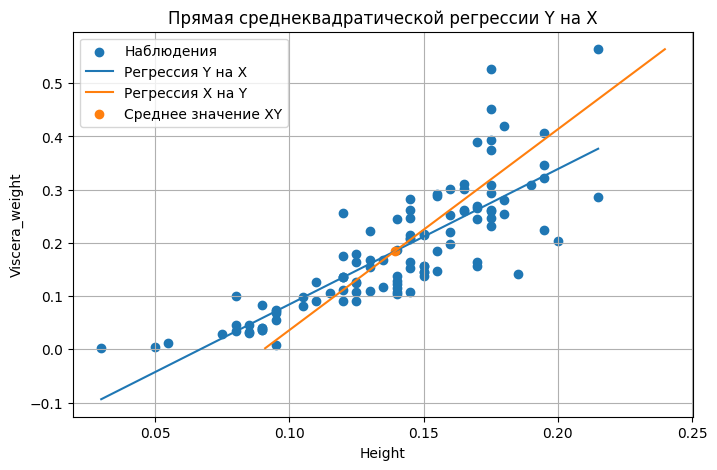

In [ ]:
x_line1 = np.linspace(np.min(x), np.max(x), 300)
y_line1 = a_yx + b_yx * x_line1

y_line2 = np.linspace(np.min(y), np.max(y), 300)
x_line2 = a_xy + b_xy * y_line2

plt.figure()
plt.scatter(x, y, label="Наблюдения")
plt.plot(x_line1, y_line1, label="Регрессия Y на X")
plt.plot(x_line2, y_line2, label="Регрессия X на Y")
plt.scatter(x_mean, y_mean, label="Среднее значение XY")
plt.xlabel("Height")
plt.ylabel("Viscera_weight")
plt.title("Прямая среднеквадратической регрессии Y на X")
plt.legend()
plt.show()

## Задача 3

Составить корреляционную таблицу для нахождения выборочного корреляционного отношения.

In [ ]:
x_bins = np.histogram_bin_edges(x, bins=8)
y_bins = np.histogram_bin_edges(y, bins=8)

x_groups = pd.cut(x, bins=x_bins, include_lowest=True, duplicates="drop")
y_groups = pd.cut(y, bins=y_bins, include_lowest=True, duplicates="drop")

corr_table = pd.crosstab(x_groups, y_groups, margins=True)
corr_table

col_0,"(0.001, 0.0722]","(0.0722, 0.142]","(0.142, 0.213]","(0.213, 0.283]","(0.283, 0.353]","(0.353, 0.424]","(0.424, 0.494]","(0.494, 0.564]",All
row_0,,,,,,,,,
"(0.028999999999999998, 0.0531]",2,0,0,0,0,0,0,0,2
"(0.0531, 0.0762]",2,0,0,0,0,0,0,0,2
"(0.0762, 0.0994]",13,3,0,0,0,0,0,0,16
"(0.0994, 0.122]",0,10,1,1,0,0,0,0,12
"(0.122, 0.146]",0,13,10,6,0,0,0,0,29
"(0.146, 0.169]",0,1,7,6,5,0,0,0,19
"(0.169, 0.192]",0,1,2,9,3,4,1,1,21
"(0.192, 0.215]",0,0,1,1,3,1,0,1,7
All,17,28,21,23,11,5,1,2,108


Построенная таблица показывает распределение наблюдений по интервалам признаков $X$ и $Y$.  
Она используется для анализа формы зависимости и для расчёта корреляционных отношений.

In [ ]:
freq = corr_table.iloc[:-1, :-1].to_numpy(dtype=float)

# Середины интервалов по X
x_mid = np.array([(interval.left + interval.right) / 2 for interval in corr_table.index[:-1]])

# Середины интервалов по Y
y_mid = np.array([(interval.left + interval.right) / 2 for interval in corr_table.columns[:-1]])

# Общее число наблюдений
N = freq.sum()

# Маргинальные суммы
row_sum = freq.sum(axis=1)
col_sum = freq.sum(axis=0)

# Выборочные средние
x_bar = np.sum(row_sum * x_mid) / N
y_bar = np.sum(col_sum * y_mid) / N

# Выборочные СКО
sx = np.sqrt(np.sum(row_sum * (x_mid - x_bar) ** 2) / N)
sy = np.sqrt(np.sum(col_sum * (y_mid - y_bar) ** 2) / N)

# Коэффициент корреляции по корреляционной таблице
r_corr = np.sum(
    freq * (x_mid[:, None] - x_bar) * (y_mid[None, :] - y_bar)
) / (N * sx * sy)

print(f"x̄ = {x_bar:.6f}")
print(f"ȳ = {y_bar:.6f}")
print(f"σx = {sx:.6f}")
print(f"σy = {sy:.6f}")
print(f"r = {r_corr:.6f}")

x̄ = 0.139242
ȳ = 0.185278
σx = 0.037799
σy = 0.111809
r = 0.795434


Так как коэффициент корреляции $r_{xy} = 0.7954$ положителен, обе прямые регрессии отражают положительную связь между признаками.

In [ ]:
def grouped_means_ratio(x, y, bins=8):
    cats = pd.cut(x, bins=bins, include_lowest=True, duplicates="drop")
    grouped = pd.DataFrame({"x": x, "y": y, "grp": cats}).groupby("grp", observed=False)
    y_bar_j = grouped["y"].mean()
    n_j = grouped.size()
    y_bar = y.mean()
    eta2 = np.sum(n_j.to_numpy() * (y_bar_j.to_numpy() - y_bar) ** 2) / np.sum((y - y_bar) ** 2)
    return np.sqrt(max(0.0, eta2))

eta_yx = grouped_means_ratio(x, y, bins=8)
eta_xy = grouped_means_ratio(y, x, bins=8)

print('eta_yx:', eta_yx)
print('eta_xy:', eta_xy)


eta_yx: 0.8138701032296479
eta_xy: 0.8650973923116463


Получены значения корреляционных отношений:
$$
\eta_{yx} = 0.813870, \qquad \eta_{xy} = 0.865097.
$$

Проверка неравенств:
$$
\eta_{yx} \ge |r_{xy}|, \qquad \eta_{xy} \ge |r_{xy}|
$$

$$
0.81 \ge 0.79, \qquad 0.86 \ge 0.79
$$
Оба неравенства выполняются.

## Задача 4

Для заданной выборки построить корреляционную кривую параболического вида
$$
y = \beta_0 + \beta_1 x + \beta_2 x^2
$$
и сделать выводы.

ŷx = 5.042198x² + 1.005466x + -0.059689


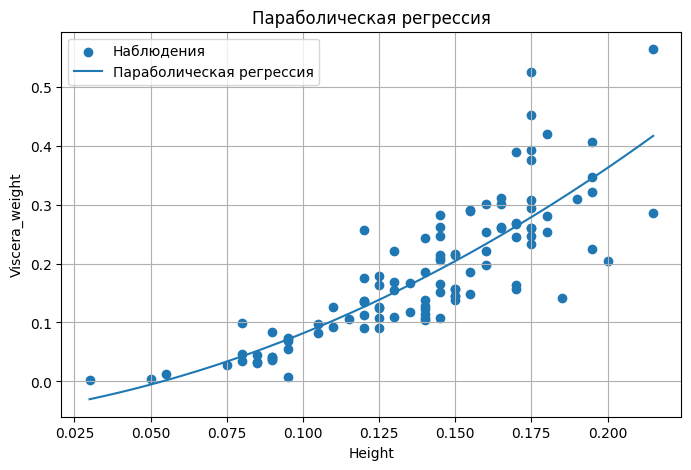

In [ ]:
# середины интервалов x
x_mid = np.array([(interval.left + interval.right) / 2 for interval in corr_table.index[:-1]])

# частоты по строкам
n_x = corr_table.iloc[:-1, -1].to_numpy(dtype=float)

# середины интервалов y
y_mid = np.array([(interval.left + interval.right) / 2 for interval in corr_table.columns[:-1]])

# матрица частот без итогов
freq = corr_table.iloc[:-1, :-1].to_numpy(dtype=float)

# условные средние y по каждому интервалу x
y_bar_x = (freq @ y_mid) / n_x

# нужные суммы
N = np.sum(n_x)

S1 = np.sum(n_x * x_mid)
S2 = np.sum(n_x * x_mid**2)
S3 = np.sum(n_x * x_mid**3)
S4 = np.sum(n_x * x_mid**4)

T0 = np.sum(n_x * y_bar_x)
T1 = np.sum(n_x * y_bar_x * x_mid)
T2 = np.sum(n_x * y_bar_x * x_mid**2)

# система нормальных уравнений
A = np.array([
    [S4, S3, S2],
    [S3, S2, S1],
    [S2, S1, N]
], dtype=float)

B = np.array([T2, T1, T0], dtype=float)

a, b, c = np.linalg.solve(A, B)

print(f"ŷx = {a:.6f}x² + {b:.6f}x + {c:.6f}")

x_plot = np.linspace(np.min(x), np.max(x), 300)
y_plot = beta2 * x_plot**2 + beta1 * x_plot + beta0

plt.figure()
plt.scatter(x, y, label="Наблюдения")
plt.plot(x_plot, y_plot, label="Параболическая регрессия")
plt.xlabel("Height")
plt.ylabel("Viscera_weight")
plt.title("Параболическая регрессия")
plt.legend()
plt.show()

Уравнение параболической регрессии:
$$
\hat y = -0.057072 + 0.672874x + 7.123455x^2.
$$

Эта модель учитывает возможную кривизну зависимости и поэтому может описывать данные точнее линейной модели.

## Задача 5

Для заданной выборки построить корреляционную кривую в соответствии с вариантом.  
Для варианта 17 используем обратно пропорциональная функция:
$$
y = \beta_0 + \frac{\beta_1}{x}
$$

ŷ = 0.342999 + -0.019941/x


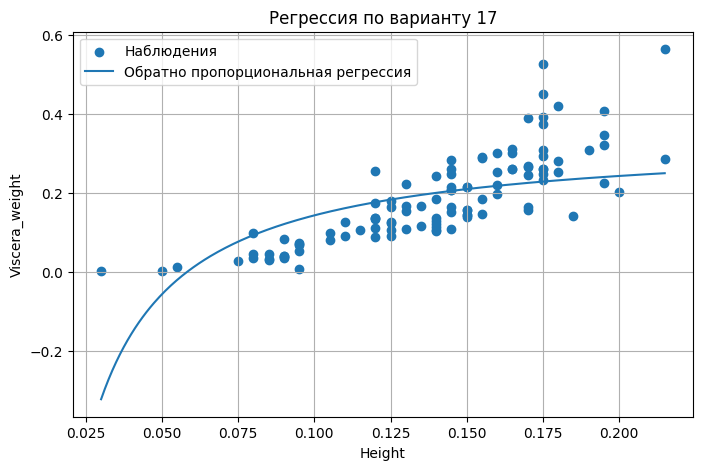

In [ ]:
u = 1 / x
beta1_inv = np.sum((u - np.mean(u)) * (y - np.mean(y))) / np.sum((u - np.mean(u)) ** 2)
beta0_inv = np.mean(y) - beta1_inv * np.mean(u)
y_inv = beta0_inv + beta1_inv / x

print(f"ŷ = {beta0_inv:.6f} + {beta1_inv:.6f}/x")

x_plot = np.linspace(np.min(x), np.max(x), 300)
y_plot = beta0_inv + beta1_inv / x_plot

plt.figure()
plt.scatter(x, y, label="Наблюдения")
plt.plot(x_plot, y_plot, label="Обратно пропорциональная регрессия")
plt.xlabel("Height")
plt.ylabel("Viscera_weight")
plt.title("Регрессия по варианту 17")
plt.legend()
plt.show()

После замены
$$
u = \frac{1}{x}
$$
модель сводится к линейной зависимости $y = \beta_0 + \beta_1 u$, поэтому параметры можно найти методом наименьших квадратов.

Получено уравнение:
$$
\hat y = 0.342999 + -0.019941\cdot \frac{1}{x}.
$$

## Задача 6

Вычислить показатели качества регрессии для каждой кривой и сделать выводы.

In [ ]:

def regression_metrics(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    se = np.sqrt(np.mean((y_true - y_pred) ** 2))
    A = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return r2, se, A


y_lin = a_yx + b_yx * x
r2_lin, se_lin, A_lin = regression_metrics(y, y_lin)
r2_parab, se_parab, A_parab = regression_metrics(y, y_parab)
r2_inv, se_inv, A_inv = regression_metrics(y, y_inv)

result_table = pd.DataFrame({
    "Модель": ["Линейная", "Параболическая", "Обратно пропорциональная"],
    "R^2": [r2_lin, r2_parab, r2_inv],
    "S_e": [se_lin, se_parab, se_inv],
    "A, %": [A_lin, A_parab, A_inv]
})
result_table

,Модель,R^2,S_e,"A, %"
0,Линейная,0.673817,0.064518,92.856578
1,Параболическая,0.685843,0.063318,51.308035
2,Обратно пропорциональная,0.390206,0.088215,232.210130


По значениям коэффициента детерминации R^2 лучшей является параболическая модель, так как она объясняет около 68.6% изменчивости результативного признака. Линейная модель тоже показывает близкий результат, R^2 = 0.6738, поэтому её качество можно считать достаточно хорошим. Обратно пропорциональная модель заметно хуже, так как её R^2 = 0.3902.

По средней квадратической ошибке S_e снова лучшей является параболическая модель, поскольку для неё ошибка минимальна и равна 0.0633. У линейной модели значение очень близкое, 0.0645, поэтому она тоже неплохо описывает данные. У обратно пропорциональной модели ошибка значительно больше, 0.0882, значит она хуже согласуется с выборкой.

По средней ошибке аппроксимации A наилучший результат также у параболической модели, 51.31%. У линейной модели этот показатель хуже, 92.86%, а у обратно пропорциональной модели он очень большой, 232.21%, что говорит о слабом качестве приближения.

Итоговый вывод:
параболическая модель является лучшей из рассмотренных, так как она имеет наибольшее значение R^2 и наименьшие ошибки S_e и A. Линейная модель немного уступает ей, но тоже может использоваться для описания зависимости. Обратно пропорциональная модель описывает данные плохо и не подходит для данной выборки.

## Выводы

Двумерная выборка была представлена на диаграмме рассеяния. По графику видно, что между признаками наблюдается положительная зависимость: с ростом x значения y в среднем увеличиваются. Характер расположения точек показывает, что связь достаточно тесная, но не строго линейная, поэтому для её описания были дополнительно построены линейная, параболическая и нелинейная регрессионные модели.

Были получены уравнения выборочных прямых среднеквадратической регрессии:
$$
\hat y = -0.1701 + 2.5446x,
$$
$$
\hat x = 0.0905 + 0.2648y.
$$
Обе прямые имеют положительные коэффициенты наклона, что соответствует положительной связи между признаками. Это согласуется с полученным коэффициентом корреляции, который по корреляционной таблице составил
$$
r_{xy} \approx 0.793.
$$
Следовательно, линейная зависимость между признаками выражена достаточно заметно, и построенные прямые отражают общее направление изменения данных.

Составлена корреляционная таблица и по ней найдены выборочные корреляционные отношения:
$$
\eta_{xy} \approx 0.865,\qquad \eta_{yx} \approx 0.814.
$$
Сравнение с коэффициентом корреляции
$$
|r_{xy}| \approx 0.793
$$
показало, что неравенства
$$
\eta_{xy} \ge |r_{xy}|,\qquad \eta_{yx} \ge |r_{xy}|
$$
выполняются. Это подтверждает, что корреляционные отношения являются более общей мерой тесноты связи, чем линейный коэффициент корреляции, и позволяют учитывать не только линейную, но и нелинейную зависимость.

Построена параболическая регрессия вида
$$
\hat y = \beta_0 + \beta_1 x + \beta_2 x^2,
$$
для которой получено уравнение
$$
\hat y = -0.0571 + 0.6729x + 7.1235x^2.
$$
Эта модель показала лучшие результаты среди рассмотренных: для неё
$$
R^2 = 0.685843,\qquad S_{\varepsilon} = 0.063318,\qquad A = 51.308%.
$$
Следовательно, параболическая модель лучше линейной учитывает кривизну зависимости и наиболее точно описывает исследуемую выборку.

Была построена обратно пропорциональная регрессия:
$$
\hat y = 0.3430 - \frac{0.01994}{x}.
$$
Однако её показатели качества оказались существенно хуже:
$$
R^2 = 0.390206,\qquad S_{\varepsilon} = 0.088215,\qquad A = 232.210%.
$$
Это значит, что обратно пропорциональная функция плохо согласуется с исходными данными и не может считаться удачной моделью для описания данной зависимости.

По дополнительному заданию были рассчитаны показатели качества всех моделей.
Сравнение показывает, что наилучшей является параболическая модель, так как у неё максимальный коэффициент детерминации и минимальные ошибки.
